In [2]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet18_Weights
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import glob
import os
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

In [3]:
class DogsVsCatsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        :param root_dir: 包含所有图片的目录路径
        :param transform: 对图片进行的预处理操作
        """
        self.root_dir = root_dir
        self.transform = transform
        # 获取该目录下所有的 jpg 图片路径
        self.image_paths = sorted(glob.glob(os.path.join(root_dir, "*.jpg")))

    def __len__(self):
        # 返回数据集的总大小
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. 根据索引获取图片路径
        img_path = self.image_paths[idx]

        # 2. 读取图片并确保是RGB格式
        image = Image.open(img_path).convert("RGB")

        # 3. 从文件名中提取标签 (如果是猫为0，狗为1)
        filename = os.path.basename(img_path)
        label = 1 if filename.startswith("dog") else 0

        # 4. 应用转换 (例如转为 Tensor, 改变大小等)
        if self.transform:
            image = self.transform(image)

        return image, label

from torch.utils.data import Subset

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

dataset_path = (
    "C:/Users/Xiaochuan/.cache/kagglehub/datasets/fotianmoyin/dogs-vs-cats/versions/1/train"
)
base_dataset = DogsVsCatsDataset(root_dir=dataset_path, transform=None)

total_size = len(base_dataset)
train_size = int(0.85 * total_size)
test_size = total_size - train_size

generator = torch.Generator().manual_seed(42)
train_indices, test_indices = random_split(
    range(total_size), [train_size, test_size], generator=generator
)

train_full = DogsVsCatsDataset(root_dir=dataset_path, transform=train_transform)
test_full = DogsVsCatsDataset(root_dir=dataset_path, transform=test_transform)

train_dataset = Subset(train_full, train_indices.indices)
test_dataset = Subset(test_full, test_indices.indices)

print(f"总数据量: {total_size}")
print(f"训练集大小: {len(train_dataset)}, 测试集大小: {len(test_dataset)}")

总数据量: 25000
训练集大小: 21250, 测试集大小: 3750


In [3]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
batch_size = 128
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True
)

In [5]:
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 100), nn.ReLU(), nn.Dropout(p=0.3), nn.Linear(100, 1)
)
model = model.to(device)

In [6]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=2e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.6, patience=5
)
# print(model)

In [7]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.eval()
    model.fc.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device).float().view(-1, 1)

        # forward
        logits = model(x)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计 loss
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        # 统计 accuracy
        preds = (logits >= 0).float()
        total_correct += (preds == y).sum().item()
        total_samples += batch_size
        # if step % 20 == 0:
        #     print(f"Step [{step}/{len(train_loader)}], Training Loss: {loss.item():.4f}")

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device).float().view(-1, 1)

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = (logits >= 0).float()
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [8]:
num_epochs = 50

train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_test_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    scheduler.step(test_loss)
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_cnn_dogs_vs_cats_resnet18.pt")

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} |"
        f"LR: {current_lr:.6f}"
    )

Epoch [1/50] Train Loss: 0.0836, Train Acc: 0.9705 | Test Loss: 0.0406, Test Acc: 0.9825 |LR: 0.001000
Epoch [2/50] Train Loss: 0.0504, Train Acc: 0.9800 | Test Loss: 0.0416, Test Acc: 0.9830 |LR: 0.001000
Epoch [3/50] Train Loss: 0.0473, Train Acc: 0.9818 | Test Loss: 0.0373, Test Acc: 0.9841 |LR: 0.001000
Epoch [4/50] Train Loss: 0.0465, Train Acc: 0.9828 | Test Loss: 0.0391, Test Acc: 0.9846 |LR: 0.001000
Epoch [5/50] Train Loss: 0.0441, Train Acc: 0.9834 | Test Loss: 0.0398, Test Acc: 0.9838 |LR: 0.001000
Epoch [6/50] Train Loss: 0.0428, Train Acc: 0.9843 | Test Loss: 0.0349, Test Acc: 0.9876 |LR: 0.001000
Epoch [7/50] Train Loss: 0.0424, Train Acc: 0.9829 | Test Loss: 0.0390, Test Acc: 0.9841 |LR: 0.001000
Epoch [8/50] Train Loss: 0.0426, Train Acc: 0.9832 | Test Loss: 0.0313, Test Acc: 0.9892 |LR: 0.001000
Epoch [9/50] Train Loss: 0.0400, Train Acc: 0.9845 | Test Loss: 0.0315, Test Acc: 0.9881 |LR: 0.001000
Epoch [10/50] Train Loss: 0.0409, Train Acc: 0.9838 | Test Loss: 0.0317, 

In [14]:
import inspect
from torchvision.models.resnet import ResNet, BasicBlock

print(inspect.getsource(ResNet._forward_impl))
print(inspect.getsource(BasicBlock.forward))

    def _forward_impl(self, x: Tensor) -> Tensor:
        # See note [TorchScript super()]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out



Best test acc: 0.9906


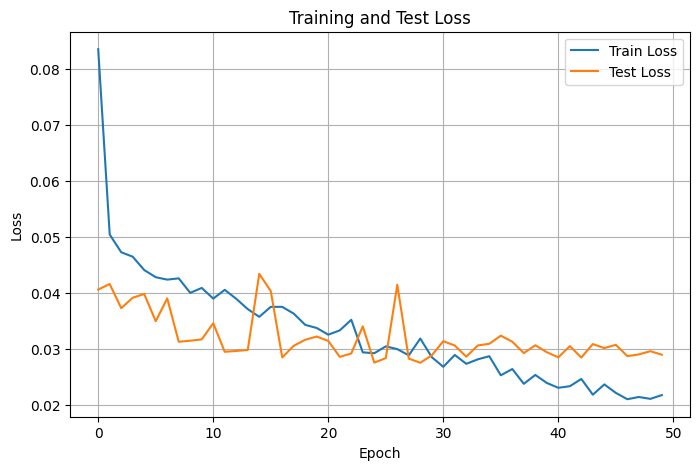

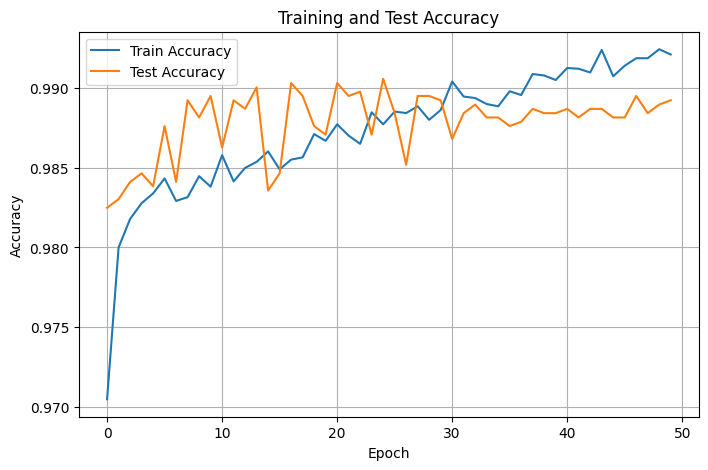

In [12]:
print(f"Best test acc: {best_test_acc:.4f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Fine Tuning

In [5]:
model = models.resnet18(weights=None)

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 100), nn.ReLU(), nn.Dropout(p=0.3), nn.Linear(100, 1)
)

# 3. 加载保存的参数
state_dict = torch.load("best_cnn_dogs_vs_cats_resnet18.pt", map_location=device)
model.load_state_dict(state_dict)

# 4. 移动到 device
model = model.to(device)


In [6]:
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

In [7]:
batch_size = 128
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True
)

In [ ]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4},
    ],
    weight_decay=1e-5,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.65, patience=4
)
# print(model)

In [10]:
def set_bn_eval(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    model.apply(set_bn_eval)
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device).float().view(-1, 1)

        # forward
        logits = model(x)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计 loss
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        # 统计 accuracy
        preds = (logits >= 0).float()
        total_correct += (preds == y).sum().item()
        total_samples += batch_size
        # if step % 20 == 0:
        #     print(f"Step [{step}/{len(train_loader)}], Training Loss: {loss.item():.4f}")

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device).float().view(-1, 1)

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = (logits >= 0).float()
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [11]:
num_epochs = 50

train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_test_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    scheduler.step(test_loss)
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_cnn_dogs_vs_cats_resnet18_fine-tuning.pt")

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} |"
        f"LR: {current_lr:.6f}"
    )

Epoch [1/50] Train Loss: 0.0313, Train Acc: 0.9879 | Test Loss: 0.0264, Test Acc: 0.9906 |LR: 0.000010
Epoch [2/50] Train Loss: 0.0271, Train Acc: 0.9903 | Test Loss: 0.0257, Test Acc: 0.9895 |LR: 0.000010
Epoch [3/50] Train Loss: 0.0254, Train Acc: 0.9906 | Test Loss: 0.0309, Test Acc: 0.9876 |LR: 0.000010
Epoch [4/50] Train Loss: 0.0239, Train Acc: 0.9912 | Test Loss: 0.0279, Test Acc: 0.9900 |LR: 0.000010
Epoch [5/50] Train Loss: 0.0187, Train Acc: 0.9931 | Test Loss: 0.0297, Test Acc: 0.9895 |LR: 0.000010
Epoch [6/50] Train Loss: 0.0175, Train Acc: 0.9938 | Test Loss: 0.0284, Test Acc: 0.9903 |LR: 0.000010
Epoch [7/50] Train Loss: 0.0155, Train Acc: 0.9942 | Test Loss: 0.0291, Test Acc: 0.9911 |LR: 0.000007
Epoch [8/50] Train Loss: 0.0151, Train Acc: 0.9941 | Test Loss: 0.0278, Test Acc: 0.9925 |LR: 0.000007
Epoch [9/50] Train Loss: 0.0136, Train Acc: 0.9952 | Test Loss: 0.0284, Test Acc: 0.9919 |LR: 0.000007
Epoch [10/50] Train Loss: 0.0115, Train Acc: 0.9957 | Test Loss: 0.0306, 

Best test acc: 0.9925


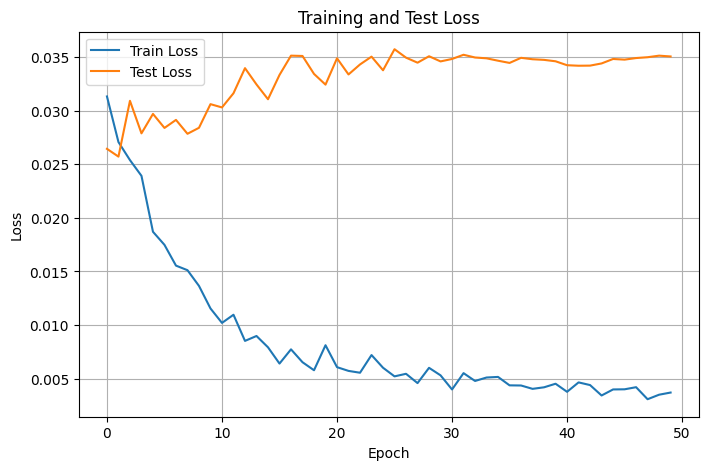

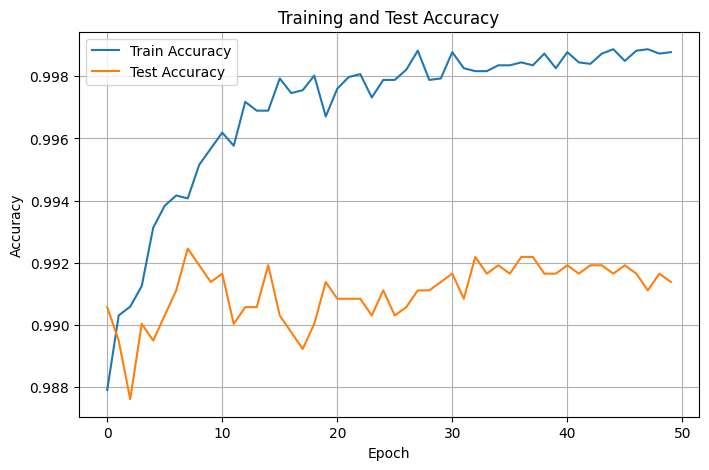

In [12]:
print(f"Best test acc: {best_test_acc:.4f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()